In [4]:
import os
import glob
import numpy as np
import cv2
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch
from torchvision import transforms
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [5]:
dataset_path = 'hand-keypoints/labels/train/*.txt'

files = glob.glob(dataset_path, recursive=True)

count_neg = 0       # Đếm số điểm < 0 (tràn trên/trái)
count_overflow = 0  # Đếm số điểm > 1 (tràn dưới/phải)
files_with_issue = set()

for file_path in files:
    with open(file_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        data = list(map(float, line.strip().split()))

        # Bỏ qua 5 tham số đầu - class name, x_center, y_center, weight, height (của bouding box)
        keypoints = data[5:]

        # Kiểm tra bộ 3 tham số của từng keypoint
        for i in range(0, len(keypoints), 3):
            if i + 1 < len(keypoints):
                x = keypoints[i]
                y = keypoints[i+1]
                v = keypoints[i+2]

                # Bỏ qua các điểm bị thiếu (0,0,0) vì đó là nhiễu
                if x == 0 and y == 0:
                    continue

                # Kiểm tra < 0
                if x < 0 or y < 0:
                    count_neg += 1
                    files_with_issue.add(file_path)
                    if count_neg <= 3:
                        print(f"Tràn viền (x < 0 || y < 0) {os.path.basename(file_path)}: (x={x}, y={y}, v={v})")

                # Kiểm tra > 1
                if x > 1 or y > 1:
                    count_overflow += 1
                    files_with_issue.add(file_path)
                    if count_overflow <= 3:
                        print(f"Tràn viền (x > 1 || y > 1) {os.path.basename(file_path)}: (x={x}, y={y}, v={v})")

print(f"Số điểm (x < 0 || y < 0): {count_neg}")
print(f"Số điểm (x > 1 || y > 1): {count_overflow}")

Tràn viền (x > 1 || y > 1) IMG_00009394.txt: (x=0.2517744302749634, y=1.032221794128418, v=2.0)
Tràn viền (x > 1 || y > 1) IMG_00009394.txt: (x=0.24855747818946838, y=1.0411745309829712, v=2.0)
Tràn viền (x > 1 || y > 1) IMG_00009394.txt: (x=0.2145073115825653, y=1.0512971878051758, v=2.0)
Số điểm (x < 0 || y < 0): 0
Số điểm (x > 1 || y > 1): 1111


In [6]:
def parse_label_line(line):
    # Hàm tách chuỗi thành các tham số.
    # line: dòng text trong file .txt
    # output: 68 tham số của 1 bàn tay
    parts = line.strip().split()

    class_name = int(parts[0])

    bbox = [float(x) for x in parts[1:5]]

    raw_kpts = [float(x) for x in parts[5:]]

    keypoints = []
    for i in range(0, len(raw_kpts), 3):
        if (i + 2 < len(raw_kpts)):
            x = raw_kpts[i]
            y = raw_kpts[i+1]
            v = raw_kpts[i+2]

            keypoints.append([x, y, v])

    return class_name, bbox, keypoints

# Test
sample_line = "0 0.46651785714285715 0.49107142857142855 0.3169642857142857 0.5357142857142857 0.48309236764907837 0.7163426876068115 2 0.4174393117427826 0.6634458303451538 2 0.38377609848976135 0.5823003053665161 2 0.37617403268814087 0.5101341605186462 2 0.3530091941356659 0.4554878771305084 2 0.438473105430603 0.4833811819553375 2 0.44120508432388306 0.3922432065010071 2 0.4463641047477722 0.3399854302406311 2 0.4518919587135315 0.294249951839447 2 0.4861244261264801 0.4816085696220398 2 0.4931791126728058 0.3834184408187866 2 0.4972662925720215 0.32293981313705444 2 0.49901512265205383 0.2714407742023468 2 0.5287731289863586 0.49805980920791626 2 0.5356495976448059 0.40958815813064575 2 0.5379229784011841 0.3564436137676239 2 0.5372802019119263 0.31134337186813354 2 0.5707579255104065 0.5304220914840698 2 0.5823127627372742 0.46903520822525024 2 0.584537148475647 0.429551362991333 2 0.5842128396034241 0.3944624662399292 2"

cls_id, box, kpts = parse_label_line(sample_line)

print(f"Class name: {cls_id}")
print(f"Bounding Box (x, y, w, h): {box}")
print(f"Số lượng Keypoints: {len(kpts)}")
print(f"Keypoint đầu tiên (x, y, v): {kpts[0]}")

Class name: 0
Bounding Box (x, y, w, h): [0.46651785714285715, 0.49107142857142855, 0.3169642857142857, 0.5357142857142857]
Số lượng Keypoints: 21
Keypoint đầu tiên (x, y, v): [0.48309236764907837, 0.7163426876068115, 2.0]


In [7]:
def resize_image(image_path, target_size=(224, 224)):
    # Hàm resize lại ảnh đầu vào
    # image_path: đường dẫn ảnh đầu vào
    # target_size: kích thước muốn resize

    img = cv2.imread(image_path)

    if img is None:
        print(f"Không tìm thấy ảnh {image_path}")
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    resized_img = cv2.resize(img_rgb, target_size, interpolation=cv2.INTER_LINEAR)

    return resized_img

# Test
path = "hand-keypoints/images/train/IMG_00000001.jpg"
img_out = resize_image(path)
print(f"Resize: {img_out.shape}")

Resize: (224, 224, 3)


In [8]:
pytorch_transform = transforms.Compose([
    transforms.ToTensor(),  # Chuyển Numpy (H,W,C) -> Tensor (C,H,W), chia 255 -> [0,1]
    transforms.Normalize(   # Chuẩn hóa theo ImageNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print(pytorch_transform)

Compose(
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [9]:
class HandKeypointsDataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None):
        """
        img_dir: Đường dẫn thư mục ảnh ('hand-keypoints/images/train')
        label_dir: Đường dẫn thư mục nhãn ('hand-keypoints/labels/train')
        transform: Phép biến đổi của PyTorch (đã khai báo ở trên)
        """
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform

        self.img_files = sorted(glob.glob(os.path.join(img_dir, "*.jpg")))

        if len(self.img_files) == 0:
            print(f"Không tìm thấy ảnh nào trong {img_dir}")

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = self.img_files[idx]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img_resized = cv2.resize(img, (224, 224), interpolation=cv2.INTER_LINEAR)

        if self.transform:
            img_tensor = self.transform(img_resized)

        # Tìm file .txt tương ứng
        filename = os.path.basename(img_path)
        label_name = os.path.splitext(filename)[0] + ".txt"
        label_path = os.path.join(self.label_dir, label_name)

        target_vector = []

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                line = f.readline().strip().split()

                bbox = [float(x) for x in line[1:5]]

                kpts = []
                raw_kpts = [float(x) for x in line[5:]]

                for i in range(0, len(raw_kpts), 3):
                    x = raw_kpts[i]
                    y = raw_kpts[i+1]

                    x = np.clip(x, 0.0, 1.0)
                    y = np.clip(y, 0.0, 1.0)
                    kpts.extend([x, y])

                target_vector = bbox + kpts

        target_tensor = torch.tensor(target_vector, dtype=torch.float32)

        return img_tensor, target_tensor

In [10]:
train_dataset = HandKeypointsDataset(
    img_dir='hand-keypoints/images/train',
    label_dir='hand-keypoints/labels/train',
    transform=pytorch_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

# Test
images, targets = next(iter(train_loader))

print(f"Kích thước Batch ảnh: {images.shape}")
print(f"Kích thước Batch nhãn: {targets.shape}")

Kích thước Batch ảnh: torch.Size([32, 3, 224, 224])
Kích thước Batch nhãn: torch.Size([32, 46])


In [11]:
# Kernel Filter
"""
in_planes : số kênh (channels/depth)
out_planes : số filter
kernel_size : kích thước kernel
stride : bước nhảy
padding : bộ đệm
"""
def conv3x3(in_planes, out_planes, stride=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)

def conv1x1(in_planes, out_planes, stride=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride,
                     bias=False)

# Basic Block
class BasicBlock(nn.Module):
    expansion = 1  # ResNet-18 không tăng channel ở block

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = conv3x3(in_channels, out_channels, stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = conv3x3(out_channels, out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # Nếu size/channel thay đổi thì dùng downsample
        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out

In [12]:
class ResNet18(nn.Module):
    def __init__(self, num_keypoints=21):
        super().__init__()

        self.in_channels = 64

        # Stem
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Body (4 stages)
        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)

        # Head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, 46)

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None

        # Nếu stride != 1 hoặc channel thay đổi -> shortcut phải conv1x1
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                conv1x1(self.in_channels, out_channels, stride),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels

        # Các block còn lại stride=1
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        # Stem
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # 4 stages
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Head
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet18(num_keypoints=21).to(device)

In [14]:
criterion_bbox = nn.MSELoss()
criterion_kp   = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 30

for epoch in range(num_epochs):

    model.train()
    total_loss = 0

    for batch_idx, (images, targets) in enumerate(train_loader):
        print(f"Epoch {epoch+1}, Batch {batch_idx+1}/{len(train_loader)}")

        images  = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        bbox_pred = outputs[:, :4]
        bbox_gt   = targets[:, :4]

        kp_pred   = outputs[:, 4:]
        kp_gt     = targets[:, 4:]

        bbox_loss = criterion_bbox(bbox_pred, bbox_gt)
        kp_loss   = criterion_kp(kp_pred, kp_gt)


        loss = bbox_loss + kp_loss

        # print(f"    BBox Loss    : {bbox_loss.item():.6f}")
        # print(f"    KP Loss      : {kp_loss.item():.6f}")
        # print(f"    Total Loss   : {loss.item():.6f}")

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} DONE - Avg Loss: {avg_loss:.6f}")


Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
Epoch 22, Batch 293/587
Epoch 22, Batch 294/587
Epoch 22, Batch 295/587
Epoch 22, Batch 296/587
Epoch 22, Batch 297/587
Epoch 22, Batch 298/587
Epoch 22, Batch 299/587
Epoch 22, Batch 300/587
Epoch 22, Batch 301/587
Epoch 22, Batch 302/587
Epoch 22, Batch 303/587
Epoch 22, Batch 304/587
Epoch 22, Batch 305/587
Epoch 22, Batch 306/587
Epoch 22, Batch 307/587
Epoch 22, Batch 308/587
Epoch 22, Batch 309/587
Epoch 22, Batch 310/587
Epoch 22, Batch 311/587
Epoch 22, Batch 312/587
Epoch 22, Batch 313/587
Epoch 22, Batch 314/587
Epoch 22, Batch 315/587
Epoch 22, Batch 316/587
Epoch 22, Batch 317/587
Epoch 22, Batch 318/587
Epoch 22, Batch 319/587
Epoch 22, Batch 320/587
Epoch 22, Batch 321/587
Epoch 22, Batch 322/587
Epoch 22, Batch 323/587
Epoch 22, Batch 324/587
Epoch 22, Batch 325/587
Epoch 22, Batch 326/587
Epoch 22, Batch 327/587
Epoch 22, Batch 328/587
Epoch 22, Batch 329/587
Epoch 22, Batch 330/587
Epoch 22, Batch 331/587
Epoch 2

In [15]:
from PIL import Image
import torchvision.transforms as transforms
import torch

def predict_from_path(model, image_path, device):
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    # Load ảnh
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0)  # [1, 3, 224, 224]

    with torch.no_grad():
        image = image.to(device)
        outputs = model(image)

        bbox = outputs[:, :4]
        keypoints = outputs[:, 4:]

    return bbox.cpu(), keypoints.cpu()
image_path = "hand-keypoints/images/val/IMG_00000002.jpg"

bbox, keypoints = predict_from_path(model, image_path, device)

print("BBox:", bbox)        # [1, 4]
print("Keypoints:", keypoints)  # [1, 42]



BBox: tensor([[0.4485, 0.5918, 0.5256, 0.6610]])
Keypoints: tensor([[0.4393, 0.8846, 0.4621, 0.8094, 0.5267, 0.6891, 0.5813, 0.6125, 0.6250,
         0.5637, 0.4585, 0.5689, 0.4733, 0.4494, 0.4482, 0.4106, 0.4494, 0.3934,
         0.4186, 0.5591, 0.4285, 0.3995, 0.4180, 0.3386, 0.4258, 0.2952, 0.4010,
         0.5866, 0.3840, 0.4553, 0.3972, 0.3954, 0.3826, 0.3475, 0.3967, 0.6456,
         0.3633, 0.5564, 0.3581, 0.4872, 0.3269, 0.4483]])


In [16]:
import torch
import numpy as np

def keypoint_accuracy(
    outputs,
    targets,
    thresholds=np.linspace(0.001, 0.05, 10)
):
    """
    outputs, targets: [B, 46]
    thresholds: list ngưỡng sai lệch (normalized)
    return: dict {threshold: accuracy}
    """

    kp_pred = outputs[:, 4:]
    kp_gt   = targets[:, 4:]

    B = kp_pred.shape[0]
    K = kp_pred.shape[1] // 2

    kp_pred = kp_pred[:, :K*2].view(B, K, 2)
    kp_gt   = kp_gt[:, :K*2].view(B, K, 2)

    dist = torch.norm(kp_pred - kp_gt, dim=2)  # [B, K]

    acc_results = {}

    for th in thresholds:
        acc = (dist < th).float().mean().item()
        acc_results[f"{th*100:.2f}%"] = acc

    return acc_results


In [17]:
val_dataset = HandKeypointsDataset(
    img_dir='hand-keypoints/images/val',
    label_dir='hand-keypoints/labels/val',
    transform=pytorch_transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)
with torch.no_grad():
    images, targets = next(iter(val_loader))
    images  = images.to(device)
    targets = targets.to(device)

    outputs = model(images)

    acc_results = keypoint_accuracy(outputs, targets)

    for th, acc in acc_results.items():
        print(f"Threshold {th} | Accuracy: {acc:.4f}")



Threshold 0.10% | Accuracy: 0.0000
Threshold 0.64% | Accuracy: 0.0119
Threshold 1.19% | Accuracy: 0.0476
Threshold 1.73% | Accuracy: 0.0893
Threshold 2.28% | Accuracy: 0.1399
Threshold 2.82% | Accuracy: 0.2113
Threshold 3.37% | Accuracy: 0.2842
Threshold 3.91% | Accuracy: 0.3616
Threshold 4.46% | Accuracy: 0.4152
Threshold 5.00% | Accuracy: 0.4732


In [18]:
def evaluate_model(model, dataloader, device, thresholds=np.linspace(0.0001, 0.1, 10)):
    model.eval() # Chuyển sang chế độ đánh giá

    total_correct = {f"{th*100:.2f}%": 0 for th in thresholds}
    total_points = 0

    with torch.no_grad():
        for images, targets in dataloader:
            images = images.to(device)
            targets = targets.to(device)

            outputs = model(images)

            kp_pred = outputs[:, 4:]
            kp_gt   = targets[:, 4:]

            B = kp_pred.shape[0]
            K = kp_pred.shape[1] // 2

            kp_pred = kp_pred[:, :K*2].view(B, K, 2)
            kp_gt   = kp_gt[:, :K*2].view(B, K, 2)

            dist = torch.norm(kp_pred - kp_gt, dim=2) # [B, K]

            total_points += (B * K)

            for th in thresholds:
                correct_count = (dist < th).sum().item()
                total_correct[f"{th*100:.2f}%"] += correct_count

    # Tính trung bình sau khi duyệt hết dữ liệu
    print("KẾT QUẢ ĐÁNH GIÁ")
    final_results = {}
    for key, count in total_correct.items():
        acc = count / total_points
        final_results[key] = acc
        print(f"Threshold {key} | Accuracy: {acc:.4f}")

    return final_results

# Test
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

evaluate_model(model, val_loader, device)

KẾT QUẢ ĐÁNH GIÁ
Threshold 0.01% | Accuracy: 0.0000
Threshold 1.12% | Accuracy: 0.1608
Threshold 2.23% | Accuracy: 0.4567
Threshold 3.34% | Accuracy: 0.6789
Threshold 4.45% | Accuracy: 0.7993
Threshold 5.56% | Accuracy: 0.8613
Threshold 6.67% | Accuracy: 0.8977
Threshold 7.78% | Accuracy: 0.9206
Threshold 8.89% | Accuracy: 0.9363
Threshold 10.00% | Accuracy: 0.9480


{'0.01%': 1.191667858334525e-05,
 '1.12%': 0.16075003575003574,
 '2.23%': 0.4567484150817484,
 '3.34%': 0.6788931788931789,
 '4.45%': 0.799341007674341,
 '5.56%': 0.8612898612898613,
 '6.67%': 0.8977310643977311,
 '7.78%': 0.9206408789742123,
 '8.89%': 0.9362517279183946,
 '10.00%': 0.9479539062872396}

In [19]:
def evaluate_model_by_parts(model, dataloader, device, thresholds=np.linspace(0.001, 0.1, 10)):
    model.eval()

    parts_indices = {
        'Overall': list(range(21)),           # Toàn bộ 21 điểm
        'Wrist': [0],                         # Cổ tay
        'Fingertips': [4, 8, 12, 16, 20],     # 5 đầu ngón tay

        # Chi tiết từng ngón
        'Thumb': [1, 2, 3, 4],
        'Index': [5, 6, 7, 8],
        'Middle': [9, 10, 11, 12],
        'Ring': [13, 14, 15, 16],
        'Pinky': [17, 18, 19, 20]
    }

    results_count = {part: {f"{th:.4f}": 0 for th in thresholds} for part in parts_indices}
    total_points_per_part = {part: 0 for part in parts_indices}

    with torch.no_grad():
        for images, targets in dataloader:
            images = images.to(device)
            targets = targets.to(device)

            outputs = model(images)
            kp_pred = outputs[:, 4:]
            kp_gt   = targets[:, 4:]

            B = kp_pred.shape[0]
            K = kp_pred.shape[1] // 2

            kp_pred = kp_pred.view(B, K, 2)
            kp_gt   = kp_gt.view(B, K, 2)

            dist = torch.norm(kp_pred - kp_gt, dim=2)

            for part_name, indices in parts_indices.items():
                dist_part = dist[:, indices]

                total_points_per_part[part_name] += (B * len(indices))

                for th in thresholds:
                    correct = (dist_part < th).sum().item()
                    results_count[part_name][f"{th:.4f}"] += correct

    final_results = {part: {} for part in parts_indices}

    print("-" * 115)
    print(f"{'Threshold':<15} | {'Overall':<8} | {'Wrist':<8} | {'Tips':<8} | {'Thumb':<8} | {'Index':<8} | {'Middle':<8} | {'Ring':<8} | {'Pinky':<8}")
    print("-" * 115)

    for th in thresholds:
        th_key = f"{th:.4f}"
        row_str = f"{th*100:5.2f}% ({th_key}) | "

        columns_order = ['Overall', 'Wrist', 'Fingertips', 'Thumb', 'Index', 'Middle', 'Ring', 'Pinky']

        for part_name in columns_order:
            correct = results_count[part_name][th_key]
            total = total_points_per_part[part_name]

            acc = correct / total if total > 0 else 0
            final_results[part_name][th_key] = acc

            row_str += f"{acc:.4f}   | "

        print(row_str)

    return final_results

-------------------------------------------------------------------------------------------------------------------
Threshold       | Overall  | Wrist    | Tips     | Thumb    | Index    | Middle   | Ring     | Pinky   
-------------------------------------------------------------------------------------------------------------------
 0.10% (0.0010) | 0.0014   | 0.0011   | 0.0011   | 0.0005   | 0.0023   | 0.0018   | 0.0015   | 0.0010   | 
 1.20% (0.0120) | 0.1812   | 0.1445   | 0.1810   | 0.0941   | 0.2477   | 0.2242   | 0.1856   | 0.1637   | 
 2.30% (0.0230) | 0.4742   | 0.3910   | 0.4705   | 0.3187   | 0.5786   | 0.5609   | 0.4886   | 0.4450   | 
 3.40% (0.0340) | 0.6877   | 0.5802   | 0.6798   | 0.5548   | 0.7614   | 0.7651   | 0.7181   | 0.6658   | 
 4.50% (0.0450) | 0.8031   | 0.7058   | 0.7905   | 0.7116   | 0.8458   | 0.8618   | 0.8324   | 0.7882   | 
 5.60% (0.0560) | 0.8629   | 0.7860   | 0.8488   | 0.7974   | 0.8915   | 0.9079   | 0.8858   | 0.8509   | 
 6.70% (0.0670) | 0.89

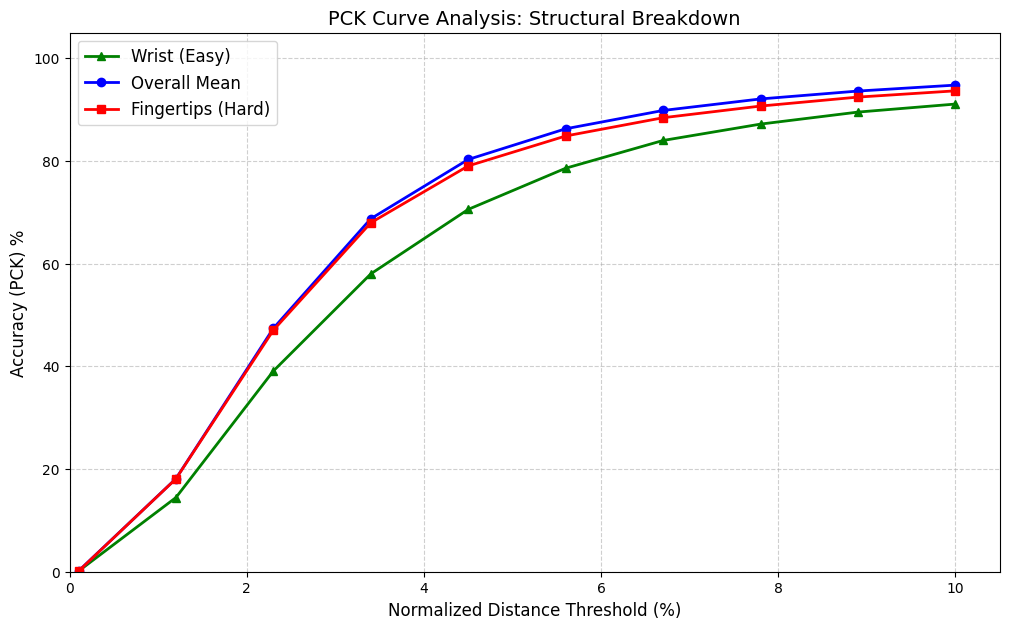

In [20]:
def plot_pck_comparison(final_results, thresholds):
    plt.figure(figsize=(12, 7))

    x_axis = [th * 100 for th in thresholds] # Đổi sang %

    parts_to_plot = ['Wrist', 'Overall', 'Fingertips']

    styles = {
        'Wrist': {'color': 'green', 'marker': '^', 'label': 'Wrist (Easy)'},
        'Overall': {'color': 'blue', 'marker': 'o', 'label': 'Overall Mean'},
        'Fingertips': {'color': 'red', 'marker': 's', 'label': 'Fingertips (Hard)'}
    }

    for part in parts_to_plot:
        y_axis = [final_results[part][f"{th:.4f}"] * 100 for th in thresholds]
        config = styles[part]
        plt.plot(x_axis, y_axis,
                 marker=config['marker'],
                 color=config['color'],
                 label=config['label'],
                 linewidth=2)

    plt.title('PCK Curve Analysis: Structural Breakdown', fontsize=14)
    plt.xlabel('Normalized Distance Threshold (%)', fontsize=12)
    plt.ylabel('Accuracy (PCK) %', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)
    plt.xlim(0, 10.5)
    plt.ylim(0, 105)
    plt.show()

# Test
thresholds_list = np.linspace(0.001, 0.1, 10) # Từ 0.1% đến 10%
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

results = evaluate_model_by_parts(model, val_loader, device, thresholds_list)

plot_pck_comparison(results, thresholds_list)

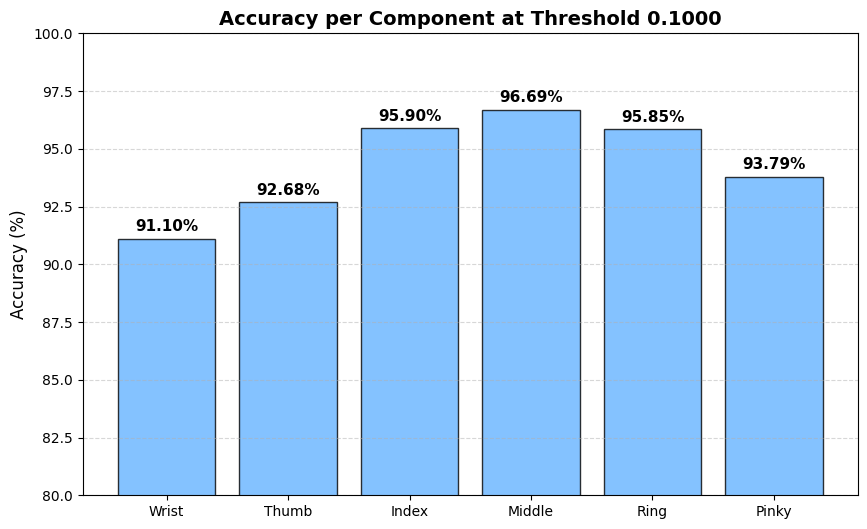

In [21]:
def plot_finger_accuracy_bar(final_results, threshold_idx=-1):
    parts = ['Wrist', 'Thumb', 'Index', 'Middle', 'Ring', 'Pinky']

    sample_key = list(final_results['Overall'].keys())[threshold_idx]

    accuracies = []
    for part in parts:
        acc = final_results[part][sample_key] * 100 # Đổi ra %
        accuracies.append(acc)

    plt.figure(figsize=(10, 6))

    colors = ['#ff6666' if x < 91 else '#66b3ff' for x in accuracies]

    bars = plt.bar(parts, accuracies, color=colors, edgecolor='black', alpha=0.8)

    plt.title(f'Accuracy per Component at Threshold {sample_key}', fontsize=14, fontweight='bold')
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.ylim(80, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                 f'{height:.2f}%',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.show()

# Test
plot_finger_accuracy_bar(results)


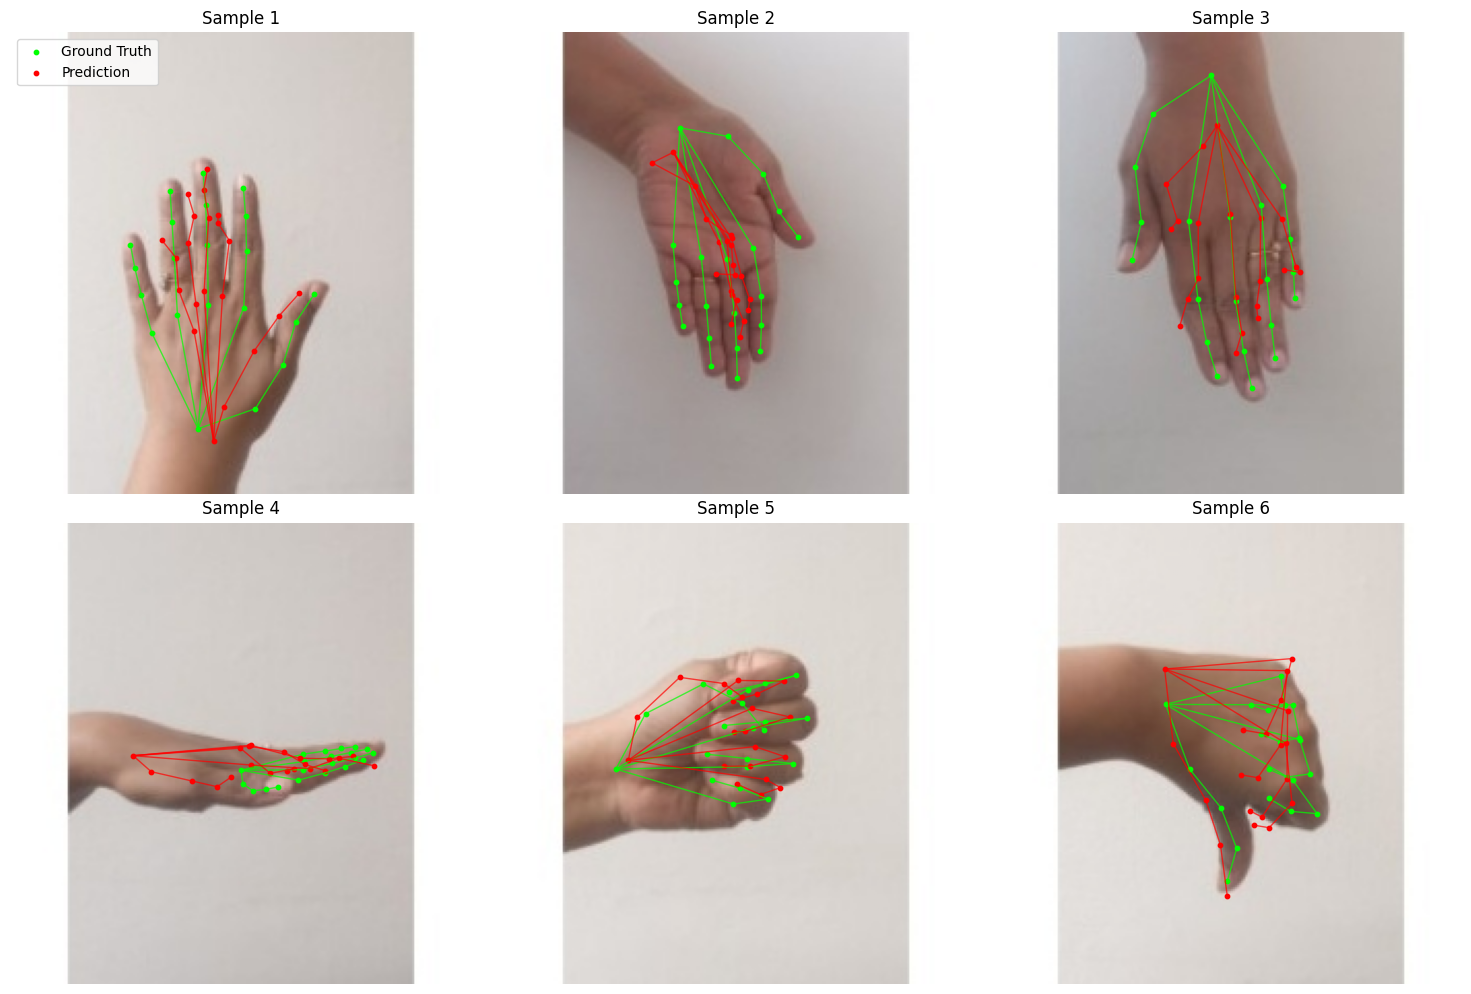

In [22]:
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),       # Ngón cái
    (0, 5), (5, 6), (6, 7), (7, 8),       # Ngón trỏ
    (0, 9), (9, 10), (10, 11), (11, 12),  # Ngón giữa
    (0, 13), (13, 14), (14, 15), (15, 16),# Ngón áp út
    (0, 17), (17, 18), (18, 19), (19, 20) # Ngón út
]

def unnormalize(tensor, mean, std):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

def visualize_comparison(model, dataloader, device, num_images=6):
    model.eval()

    images, targets = next(iter(dataloader))
    images = images.to(device)
    targets = targets.to(device)

    with torch.no_grad():
        outputs = model(images)

    kp_pred = outputs[:, 4:].view(-1, 21, 2).cpu().numpy()
    kp_gt = targets[:, 4:].view(-1, 21, 2).cpu().numpy()

    images = images.cpu()

    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]

    plt.figure(figsize=(15, 10))

    for i in range(min(num_images, len(images))):
        ax = plt.subplot(2, 3, i + 1)

        img = unnormalize(images[i].clone(), mean, std)
        img = img.numpy().transpose((1, 2, 0))
        img = np.clip(img, 0, 1)
        ax.imshow(img)

        H, W = 224, 224
        kp_pred[i] = kp_pred[i] * [W, H]
        kp_gt[i] = kp_gt[i] * [W, H]

        ax.scatter(kp_gt[i, :, 0], kp_gt[i, :, 1], c='lime', s=10, label='Ground Truth')

        for p1, p2 in HAND_CONNECTIONS:
            x = [kp_gt[i, p1, 0], kp_gt[i, p2, 0]]
            y = [kp_gt[i, p1, 1], kp_gt[i, p2, 1]]
            ax.plot(x, y, c='lime', linewidth=1, alpha=0.7)

        ax.scatter(kp_pred[i, :, 0], kp_pred[i, :, 1], c='red', s=10, label='Prediction')

        for p1, p2 in HAND_CONNECTIONS:
            x = [kp_pred[i, p1, 0], kp_pred[i, p2, 0]]
            y = [kp_pred[i, p1, 1], kp_pred[i, p2, 1]]
            ax.plot(x, y, c='red', linewidth=1, alpha=0.7)

        ax.set_title(f"Sample {i+1}")
        ax.axis('off')

        if i == 0:
            ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

# Test
visualize_comparison(model, val_loader, device, num_images=6)